In [1]:
import scanpy as sc
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import glob
import anndata as ad
import sys
sys.path.append(r'/media/data2/samba/xjlab/')

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

2024-11-13 10:54:55.462949: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-13 10:54:56.180860: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


scanpy==1.9.3 anndata==0.10.5.post1 umap==0.5.3 numpy==1.24.4 scipy==1.13.1 pandas==2.2.2 scikit-learn==1.3.0 statsmodels==0.14.1 python-igraph==0.10.6 louvain==0.7.1 pynndescent==0.5.6


In [4]:
import scanpy as sc

# 读取 .h5ad 文件
file_path = '/media/data2/samba/ssong/data/mouseALM and VIS/patch-seq.h5ad'
adata = sc.read_h5ad(file_path)

print("Data loaded successfully into 'adata'")


Data loaded successfully into 'adata'


/media/data2/samba/ssong/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:169: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/media/data2/samba/ssong/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:179: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/media/data2/samba/ssong/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored



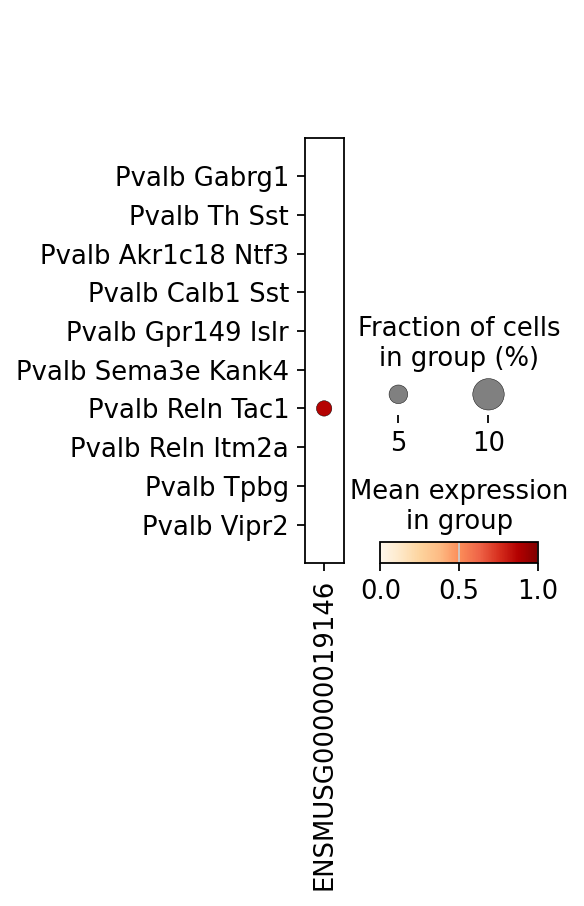

In [96]:
# 设置新的 cluster 顺序
new_order = [
    'Pvalb Gabrg1', 'Pvalb Th Sst', 'Pvalb Akr1c18 Ntf3',
    'Pvalb Calb1 Sst', 'Pvalb Gpr149 Islr', 'Pvalb Sema3e Kank4',
    'Pvalb Reln Tac1', 'Pvalb Reln Itm2a', 'Pvalb Tpbg', 'Pvalb Vipr2'
]

# 重新设置 groupby 列的顺序
adata.obs['cluster'] = adata.obs['cluster'].astype('category')
adata.obs['cluster'] = adata.obs['cluster'].cat.reorder_categories(new_order)

# 绘制 dotplot，保存为指定文件
sc.pl.dotplot(
    adata,
    var_names=['ENSMUSG00000019146'],
    groupby='cluster',
    color_map=plt.cm.OrRd,
    standard_scale='var',
    save='filtered_reordered2.svg'
)
